In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import joblib

plt.style.use("ggplot")

In [9]:
df = pd.read_csv("C:\\Users\premd\Downloads\heart_disease_dataset.csv")

In [10]:
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
0,58,1,1,134,246,0,0,155,0,0.4,1,1,2,1
1,52,0,2,112,245,0,0,143,1,0.1,0,0,3,1
2,59,0,2,126,196,0,0,162,1,1.1,1,0,1,1
3,67,1,1,165,201,0,0,180,0,0.4,2,0,2,0
4,51,1,0,146,174,1,1,133,1,0.9,1,1,2,1


In [11]:
print("Dataset Shape :", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape : (400, 14)

Column Names:
['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_induced_angina', 'st_depression', 'st_slope', 'num_major_vessels', 'thalassemia', 'heart_disease']

Data Types:
age                          int64
sex                          int64
chest_pain_type              int64
resting_blood_pressure       int64
cholesterol                  int64
fasting_blood_sugar          int64
resting_ecg                  int64
max_heart_rate               int64
exercise_induced_angina      int64
st_depression              float64
st_slope                     int64
num_major_vessels            int64
thalassemia                  int64
heart_disease                int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------          

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,400.0,53.66750,8.508403,29.0,48.0,54.0,59.0,77.0
sex,400.0,0.66250,0.473449,0.0,0.0,1.0,1.0,1.0
chest_pain_type,400.0,1.71250,1.035628,0.0,1.0,2.0,3.0,3.0
resting_blood_pressure,400.0,123.63000,16.567114,94.0,112.0,124.0,135.0,174.0
cholesterol,400.0,216.62750,41.379941,126.0,188.0,216.0,246.0,336.0
fasting_blood_sugar,400.0,0.14000,0.347422,0.0,0.0,0.0,0.0,1.0
resting_ecg,400.0,0.53000,0.533678,0.0,0.0,1.0,1.0,2.0
max_heart_rate,400.0,146.71750,21.104293,91.0,132.0,146.0,161.0,202.0
exercise_induced_angina,400.0,0.29250,0.455480,0.0,0.0,0.0,1.0,1.0
st_depression,400.0,0.75325,0.772841,0.0,0.2,0.6,0.9,4.9


In [13]:
missing = df.isnull().sum()
print(missing)

age                        0
sex                        0
chest_pain_type            0
resting_blood_pressure     0
cholesterol                0
fasting_blood_sugar        0
resting_ecg                0
max_heart_rate             0
exercise_induced_angina    0
st_depression              0
st_slope                   0
num_major_vessels          0
thalassemia                0
heart_disease              0
dtype: int64


In [14]:
duplicates = df.duplicated().sum()
print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [15]:
print("=" * 50)
print(f"Rows                : {df.shape[0]}")
print(f"Columns             : {df.shape[1]}")
print(f"Missing Values      : {df.isnull().sum().sum()}")
print(f"Duplicate Records   : {df.duplicated().sum()}")
print("=" * 50)

Rows                : 400
Columns             : 14
Missing Values      : 0
Duplicate Records   : 0


heart_disease
1    222
0    178
Name: count, dtype: int64


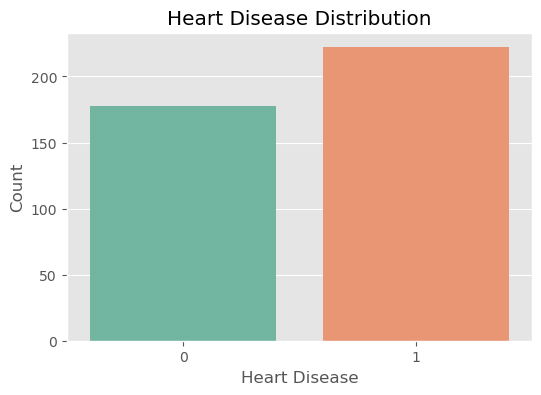

In [16]:
print(df["heart_disease"].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(
    x="heart_disease",
    data=df,
    palette="Set2"
)
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

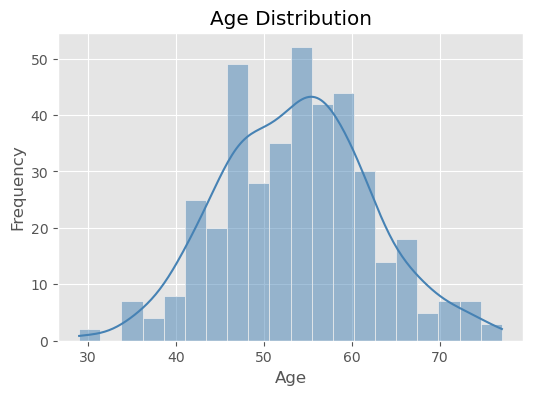

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=20, kde=True, color="steelblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

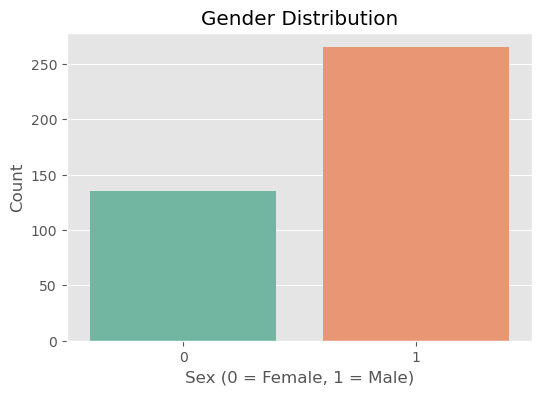

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x="sex", data=df, palette="Set2")
plt.title("Gender Distribution")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.show()

In [23]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_induced_angina', 'st_depression', 'st_slope',
       'num_major_vessels', 'thalassemia', 'heart_disease'],
      dtype='object')

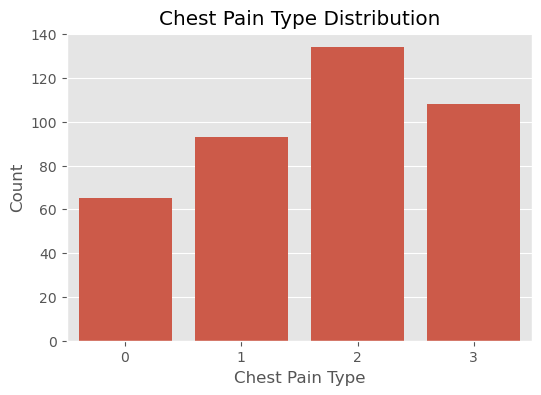

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(x="chest_pain_type", data=df)

plt.title("Chest Pain Type Distribution")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")

plt.show()

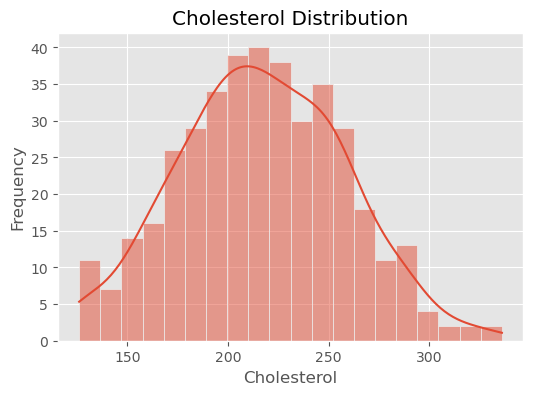

In [28]:
plt.figure(figsize=(6,4))

sns.histplot(df["cholesterol"], bins=20, kde=True)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.show()

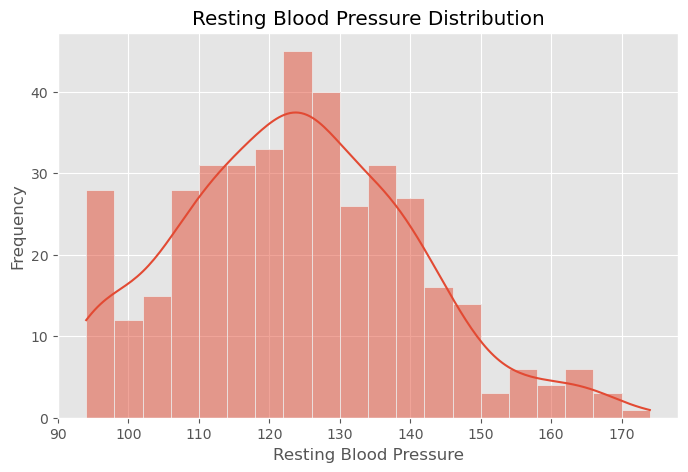

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df["resting_blood_pressure"], bins=20, kde=True)

plt.title("Resting Blood Pressure Distribution")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Frequency")

plt.show()

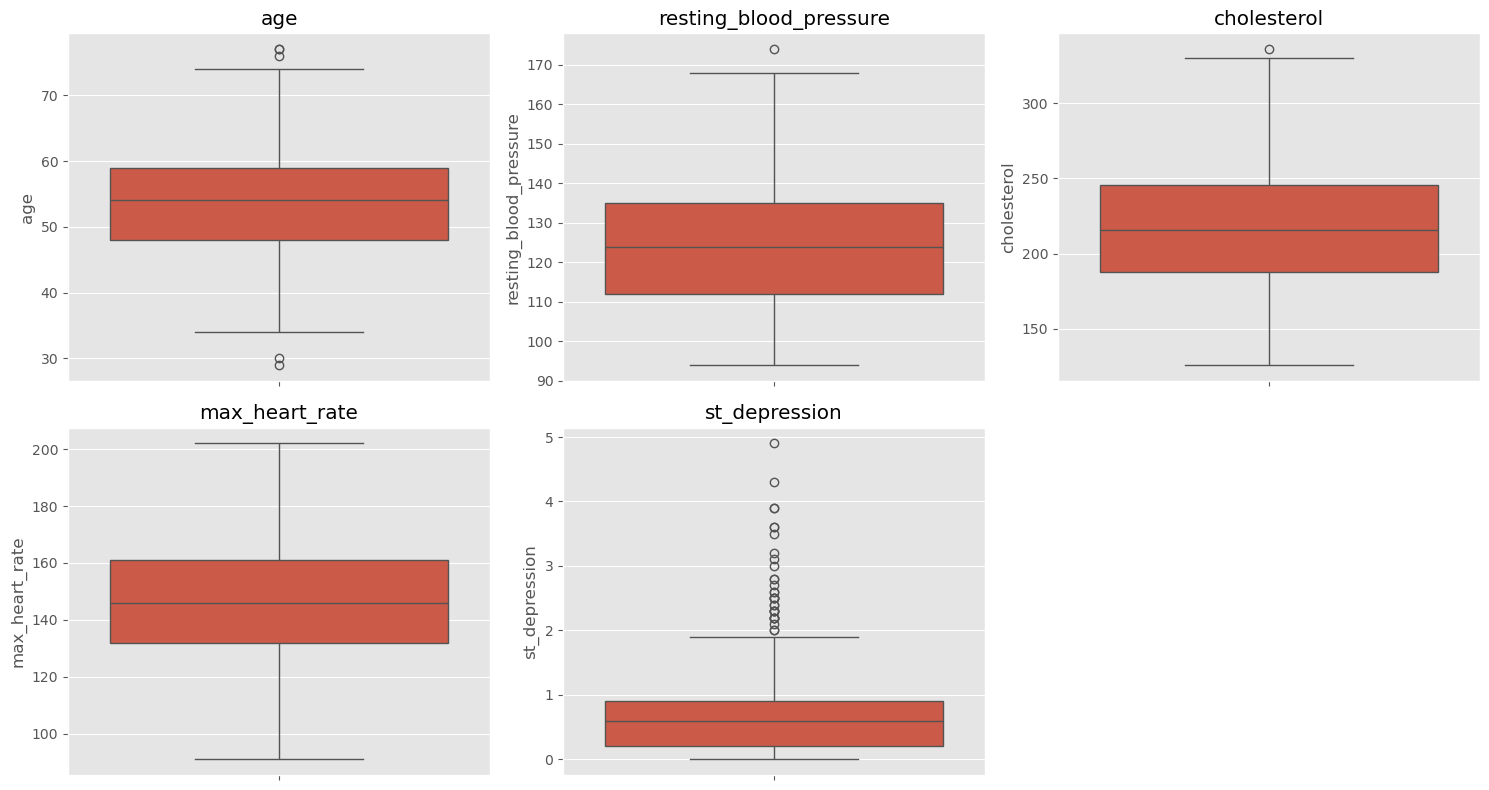

In [30]:
numeric_features = [
    "age",
    "resting_blood_pressure",
    "cholesterol",
    "max_heart_rate",
    "st_depression"
]

plt.figure(figsize=(15,8))

for i, feature in enumerate(numeric_features):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[feature])
    plt.title(feature)

plt.tight_layout()
plt.show()

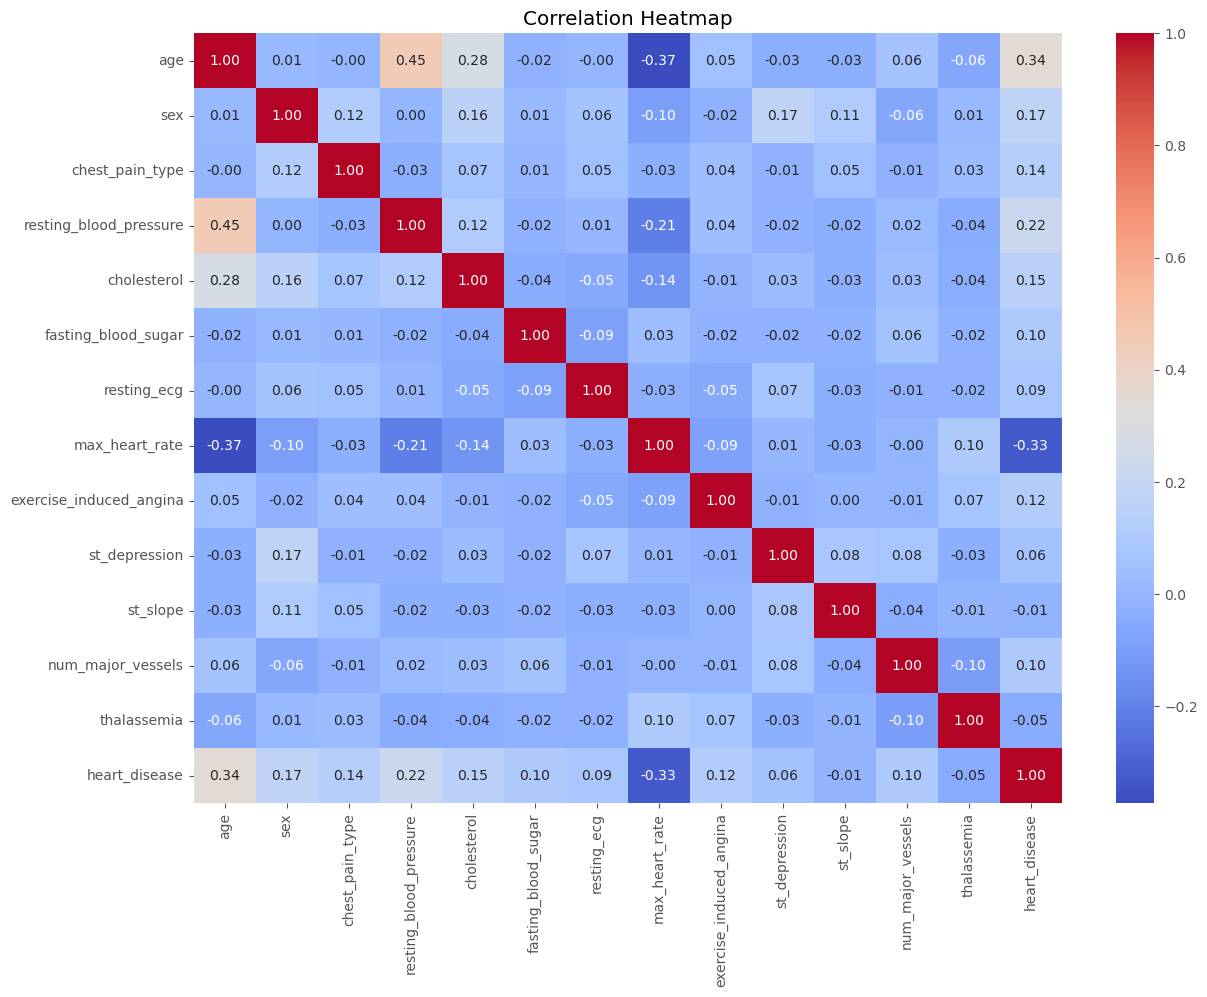

In [31]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

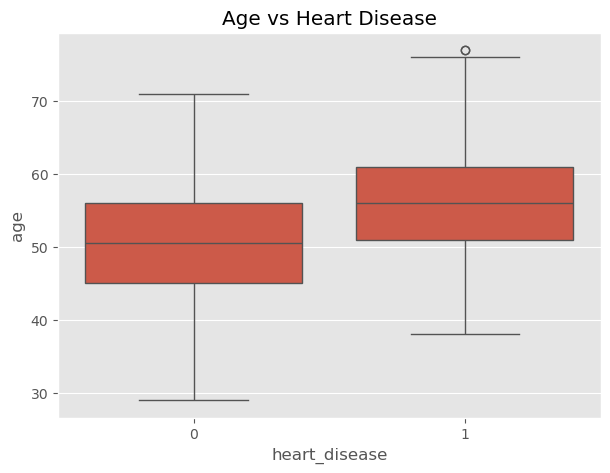

In [32]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="heart_disease",
    y="age",
    data=df
)

plt.title("Age vs Heart Disease")

plt.show()

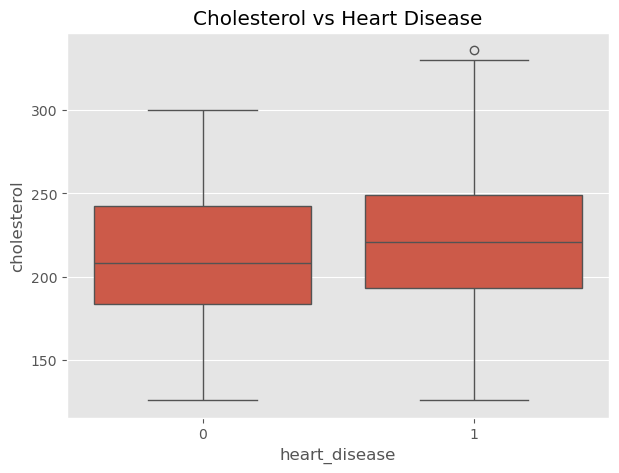

In [33]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="heart_disease",
    y="cholesterol",
    data=df
)

plt.title("Cholesterol vs Heart Disease")

plt.show()

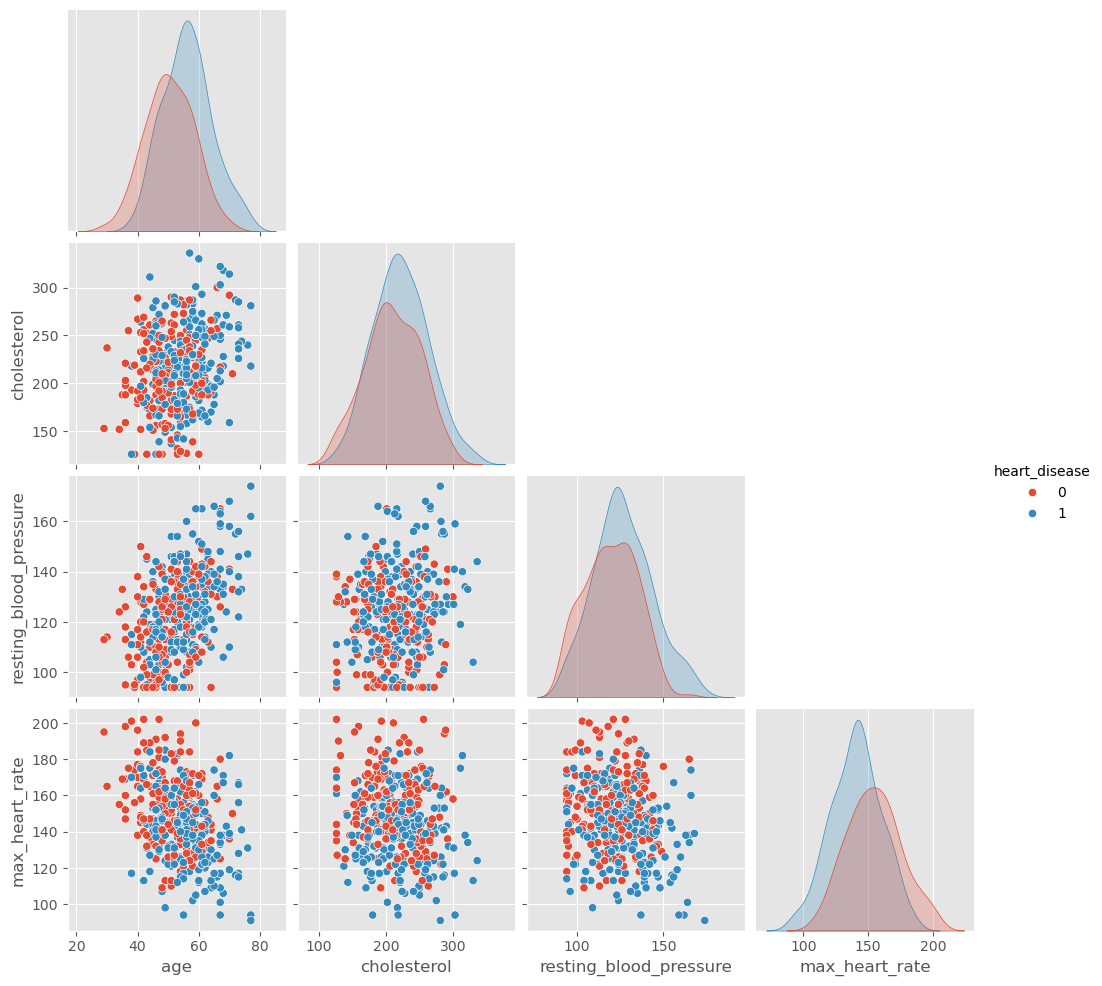

In [34]:
selected_features = [
    "age",
    "cholesterol",
    "resting_blood_pressure",
    "max_heart_rate",
    "heart_disease"
]

sns.pairplot(
    df[selected_features],
    hue="heart_disease",
    corner=True
)

plt.show()

In [35]:
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (400, 13)
Target Shape   : (400,)


In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 320
Testing Samples  : 80


In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
print("Original Shape :", X_train.shape)
print("Scaled Shape   :", X_train_scaled.shape)

Original Shape : (320, 13)
Scaled Shape   : (320, 13)


results = pd.DataFrame(
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results

Model Evaluation Function

In [40]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    
    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities (needed for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Print Results
    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )

    plt.title(model_name)
    plt.show()

    # Store Results
    global results

    results.loc[len(results)] = [
        model_name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

    return model

Logistic Regression

Logistic Regression
Accuracy : 0.6750
Precision: 0.6957
Recall   : 0.7273
F1 Score : 0.7111
ROC AUC  : 0.7342

Classification Report
              precision    recall  f1-score   support

           0       0.65      0.61      0.63        36
           1       0.70      0.73      0.71        44

    accuracy                           0.68        80
   macro avg       0.67      0.67      0.67        80
weighted avg       0.67      0.68      0.67        80



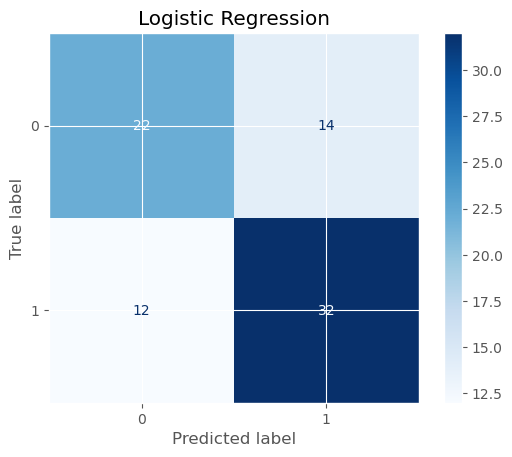

In [41]:
lr_model = LogisticRegression(random_state=42)

lr_model = evaluate_model(
    model_name="Logistic Regression",
    model=lr_model,
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test
)

Decision Tree

Decision Tree
Accuracy : 0.5875
Precision: 0.6122
Recall   : 0.6818
F1 Score : 0.6452
ROC AUC  : 0.5997

Classification Report
              precision    recall  f1-score   support

           0       0.55      0.47      0.51        36
           1       0.61      0.68      0.65        44

    accuracy                           0.59        80
   macro avg       0.58      0.58      0.58        80
weighted avg       0.58      0.59      0.58        80



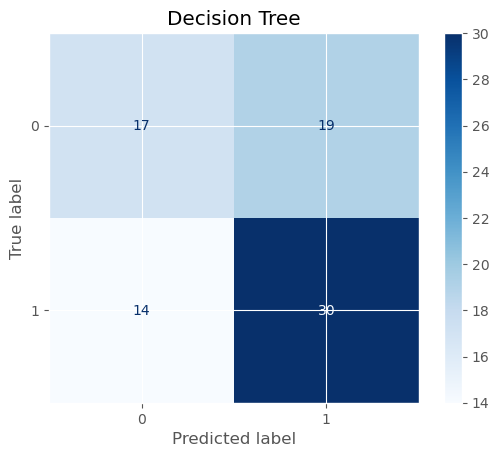

In [44]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model = evaluate_model(
    model_name="Decision Tree",
    model=dt_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

Support Vector Machine
Accuracy : 0.6500
Precision: 0.6739
Recall   : 0.7045
F1 Score : 0.6889
ROC AUC  : 0.7355

Classification Report
              precision    recall  f1-score   support

           0       0.62      0.58      0.60        36
           1       0.67      0.70      0.69        44

    accuracy                           0.65        80
   macro avg       0.65      0.64      0.64        80
weighted avg       0.65      0.65      0.65        80



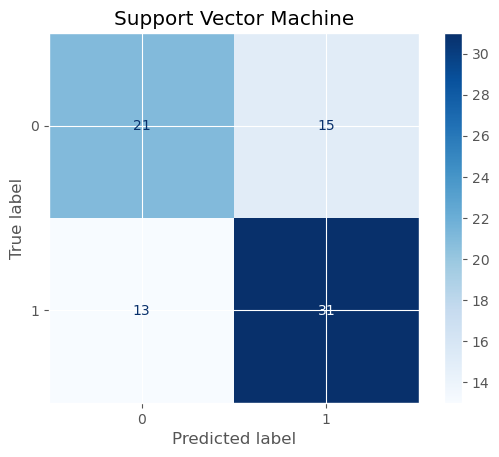

In [45]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model = evaluate_model(
    model_name="Support Vector Machine",
    model=svm_model,
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test
)

Model Comparison

In [46]:
results = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.6750,0.695652,0.727273,0.711111,0.734217
1,Support Vector Machine,0.6500,0.673913,0.704545,0.688889,0.735480
2,Support Vector Machine,0.6500,0.673913,0.704545,0.688889,0.735480
3,Decision Tree,0.5875,0.612245,0.681818,0.645161,0.599747
4,Decision Tree,0.5875,0.612245,0.681818,0.645161,0.599747


Accuracy Comparison

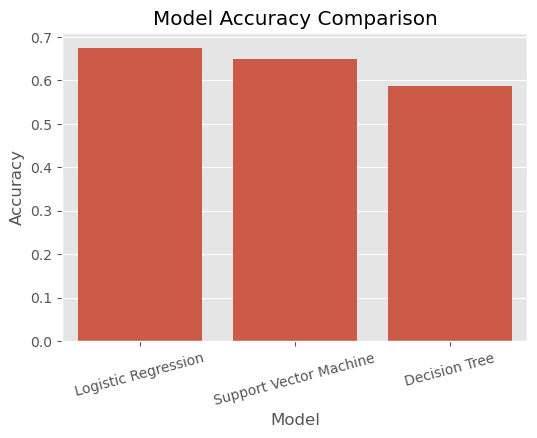

In [48]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)

plt.show()

Best Model

In [50]:
best_model_name = results.iloc[0]["Model"]
print(f"Best Performing Model : {best_model_name}")

Best Performing Model : Logistic Regression


Hyperparameter Tuning - Logistic Regression

In [52]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}

grid = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [53]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid.best_score_)

Best Parameters:
{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}

Best Cross Validation Accuracy:
0.703125


In [56]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.44      0.53        36
           1       0.64      0.82      0.72        44

    accuracy                           0.65        80
   macro avg       0.65      0.63      0.63        80
weighted avg       0.65      0.65      0.64        80



In [57]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.65
Precision: 0.6428571428571429
Recall   : 0.8181818181818182
F1 Score : 0.72


ROC Curve

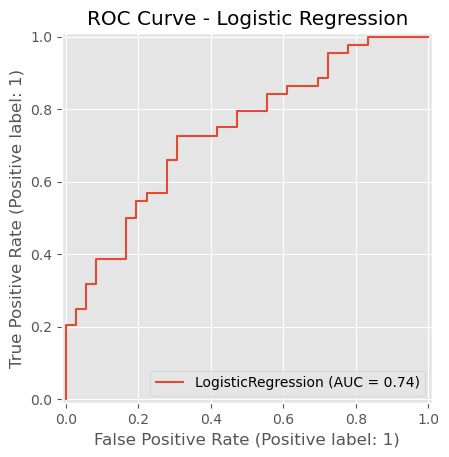

In [58]:
RocCurveDisplay.from_estimator(
    best_model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

Save Best Model

In [59]:
joblib.dump(best_model, "heart_disease_model.pkl")
print("Model saved successfully!")

Model saved successfully!


Sample Prediction

In [61]:
sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)
prediction = best_model.predict(sample_scaled)[0]
actual = y_test.iloc[0]
print("Predicted Class :", prediction)
print("Actual Class    :", actual)

Predicted Class : 1
Actual Class    : 0


Feature Importance (Logistic Regression Coefficients)

In [62]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute_Coefficient
7,max_heart_rate,-0.238098,0.238098
0,age,0.209421,0.209421
1,sex,0.168395,0.168395
3,resting_blood_pressure,0.130056,0.130056
11,num_major_vessels,0.108071,0.108071
2,chest_pain_type,0.107864,0.107864
5,fasting_blood_sugar,0.103814,0.103814
4,cholesterol,0.094050,0.094050
8,exercise_induced_angina,0.092700,0.092700
6,resting_ecg,0.077316,0.077316


Plot Feature Importance

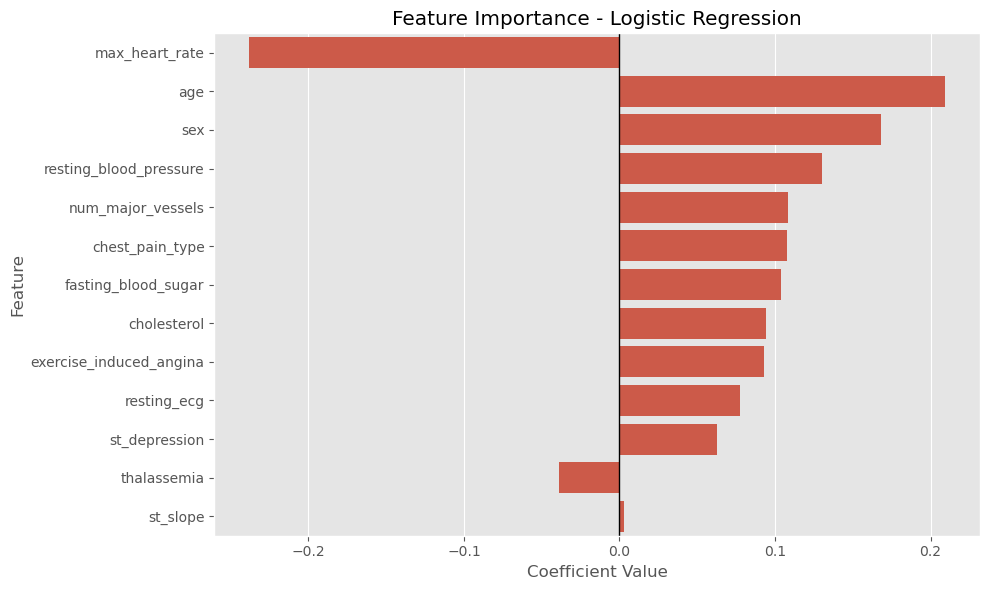

In [63]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

Top 5 Most Influential Features

In [64]:
print("Top 5 Most Influential Features:\n")
print(feature_importance[["Feature", "Coefficient"]].head())

Top 5 Most Influential Features:

                   Feature  Coefficient
7           max_heart_rate    -0.238098
0                      age     0.209421
1                      sex     0.168395
3   resting_blood_pressure     0.130056
11       num_major_vessels     0.108071


Final Model Summary

In [65]:
summary = pd.DataFrame({
    "Best Model": ["Logistic Regression"],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred)],
    "Recall": [recall_score(y_test, y_pred)],
    "F1 Score": [f1_score(y_test, y_pred)],
    "ROC AUC": [roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:, 1])]
})

summary

,Best Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.65,0.642857,0.818182,0.72,0.738636


Final Prediction Function

In [66]:
def predict_heart_disease(input_data):
    """
    Predict heart disease for a new patient.

    Parameters:
        input_data : list or array of 13 feature values

    Returns:
        Prediction (0 or 1)
    """

    input_array = np.array(input_data).reshape(1, -1)

    input_scaled = scaler.transform(input_array)

    prediction = best_model.predict(input_scaled)

    probability = best_model.predict_proba(input_scaled)

    print(f"Prediction : {prediction[0]}")
    print(f"Probability of Heart Disease : {probability[0][1]:.2%}")

    return prediction

In [67]:
sample = X.iloc[0].tolist()
predict_heart_disease(sample)

Prediction : 1
Probability of Heart Disease : 57.38%


array([1])